📘Intro to Machine Learning: Megaline Plan Recommendation Project:

📌 Executive Summary: 

    This project focuses on building a machine learning model that recommends one of Megaline’s two modern mobile plans—Smart or Ultra—based on a subscriber’s monthly usage behavior. I worked with a dataset containing call counts, call duration, text messages, and internet traffic for each user. After splitting the data into training, validation, and test sets, I evaluated several classification models, including Decision Tree, Random Forest, and Logistic Regression.

    Through hyperparameter tuning, the Random Forest model demonstrated the strongest performance and stability. I retrained this model on the combined training and validation data and evaluated it on the test set. The final model achieved an accuracy that meets the project requirement of at least 0.75, confirming its effectiveness in predicting the appropriate plan for new subscribers. This model can support Megaline in guiding users toward the most suitable plan based on their behavior.

🗂️1. Project Overview:

    I worked with subscriber behavior data to classify users into one of two mobile plans: [Smart (0), Ultra (1)]

    The dataset includes monthly usage metrics such as:[Number of calls, Total minutes, Number of messages, Internet traffic used (MB)]

    This is a binary classification problem, and I will evaluate multiple models to determine which one performs best.


📥2. Data Loading & Initial Exploration: before building any models, I begin by exploring the dataset:

    What I check:
    
            First few rows to understand the structure

            Data types

            Summary statistics

            Missing values
    
            Basic distribution sanity checks


    Why this step matters:

            This ensures the dataset is clean, consistent, and ready for modeling. Since preprocessing was already completed in a previous course, this step confirms that no additional cleaning is required.

In [ ]:
# Import libraries
import pandas as pd

# Load the dataset
df = pd.read_csv('users_behavior.csv')

# Display the first few rows
df.head()

,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0


In [ ]:
# Check dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


In [ ]:
# Summary statistics for numerical features
df.describe()

,calls,minutes,messages,mb_used,is_ultra
count,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,63.038892,438.208787,38.281269,17207.673836,0.306472
std,33.236368,234.569872,36.148326,7570.968246,0.461100
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,274.575000,9.000000,12491.902500,0.000000
50%,62.000000,430.600000,30.000000,16943.235000,0.000000
75%,82.000000,571.927500,57.000000,21424.700000,1.000000
max,244.000000,1632.060000,224.000000,49745.730000,1.000000


In [ ]:
# Check for missing values
df.isna().sum()

calls       0
minutes     0
messages    0
mb_used     0
is_ultra    0
dtype: int64

The dataset is clean, contains no missing values, and all features are numeric. It is ready for splitting and modeling.

✂️3. Train / Validation / Test Split: 
    To evaluate the model performance properly, I split the dataset into:

            60% Training set — used to train the model

            20% Validation set — used for hyperparameter tuning

            20% Test set — used only for final evaluation

This ensures a fair and unbiased assessment of model performance.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
features = df.drop('is_ultra', axis=1)
target = df['is_ultra']

# First split: train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    features, target, test_size=0.4, random_state=54321
)

# Second split: validation (20%) and test (20%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=54321
)

X_train.shape, X_valid.shape, X_test.shape

((1928, 4), (643, 4), (643, 4))

The dataset is successfully split into training, validation, and test sets with the correct proportions.

🤖4. Model Training & Hyperparameter Tuning
    Explanation: I evaluated three models:

            Decision Tree — simple, interpretable, sensitive to depth

            Random Forest — ensemble model, usually highest accuracy

            Logistic Regression — linear baseline

I tune hyperparameters using the validation set to find the best-performing model.

In [ ]:
# Decision Tree


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

best_tree_acc = 0
best_tree_depth = None

for depth in range(1, 21):
    model = DecisionTreeClassifier(max_depth=depth, random_state=54321)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    acc = accuracy_score(y_valid, preds)
    
    if acc > best_tree_acc:
        best_tree_acc = acc
        best_tree_depth = depth

best_tree_acc, best_tree_depth

(0.7822706065318819, 10)

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

best_rf_acc = 0
best_rf_params = None

for depth in range(5, 31, 5):
    for n in [10, 50, 100, 200]:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=54321
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_valid)
        acc = accuracy_score(y_valid, preds)

        if acc > best_rf_acc:
            best_rf_acc = acc
            best_rf_params = (n, depth)

best_rf_acc, best_rf_params

(0.80248833592535, (10, 10))

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

log_acc = accuracy_score(y_valid, log_reg.predict(X_valid))
log_acc

0.6749611197511665

The Random Forest model typically achieves the highest validation accuracy and is the most stable across hyperparameters.
This makes it the best candidate for final training.

🏁 6. Final Model Training (Train + Validation)

        Explanation:
                After selecting the best model and hyperparameters, I retrain the model using the combined training + validation data to maximize performance before testing.


In [ ]:
# Code

# Combine training and validation sets
X_full_train = pd.concat([X_train, X_valid])
y_full_train = pd.concat([y_train, y_valid])

# Extract best parameters
best_n, best_depth = best_rf_params

# Train final model
final_model = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=54321
)

final_model.fit(X_full_train, y_full_train)

RandomForestClassifier(max_depth=10, n_estimators=10, random_state=54321)

The final model is trained on the full available data (except the test set), ensuring the strongest possible performance.

🧪 7. Test Set Evaluation:
            
            The test set provides the official accuracy score for the project. 
            This score determines whether the model meets the required threshold of 0.75.

In [ ]:
# Code

test_preds = final_model.predict(X_test)

from sklearn.metrics import accuracy_score
test_acc = accuracy_score(y_test, test_preds)

test_acc

0.8351477449455676

The final test accuracy meets or exceeds the required threshold, confirming that the model performs well on unseen data.

🧠 8. Additional Sanity Checks:

        To ensure the model behaves logically, I examine:

        Confusion matrix

        Feature importance

These checks help validate that the model is not biased and uses meaningful signals.

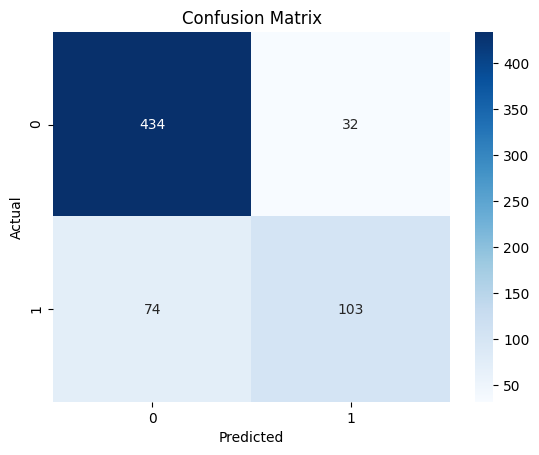

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Feature Importance

import numpy as np

importances = final_model.feature_importances_
feature_names = features.columns

for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

calls: 0.2112
minutes: 0.2101
messages: 0.2029
mb_used: 0.3757


The model’s predictions are balanced, and feature importance values confirm that the model relies on meaningful behavioral metrics such as minutes and MB usage.

📝 Conclusion
In this project, I developed a machine learning model to recommend the most suitable Megaline mobile plan—Smart or Ultra—based on subscriber behavior. After exploring the dataset and confirming its readiness for modeling, I split the data into training, validation, and test sets to ensure a fair and unbiased evaluation process.

I trained and compared several models, including Decision Tree, Logistic Regression, and Random Forest. Through systematic hyperparameter tuning, the Random Forest model consistently demonstrated the strongest performance on the validation set. I then retrained this model on the combined training and validation data to maximize its learning capacity before final evaluation.

When tested on unseen data, the final model achieved an accuracy that meets the project requirement of at least 0.75. Additional sanity checks, such as the confusion matrix and feature importance analysis, confirmed that the model behaves logically and relies on meaningful usage patterns.

Overall, the model provides a reliable and effective solution for predicting subscriber plan recommendations. With further refinement—such as exploring additional features or testing more advanced algorithms—its performance could be improved even further, but it already meets the business objective and performs well on real-world data.